<a href="https://colab.research.google.com/github/radusqrt/evolutie-discurs-nicusor-dan/blob/main/notebooks/03_bertopic_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERTopic — Evoluția discursului Nicușor Dan

Rulează pe **Google Colab cu T4 GPU** (free tier).

**Setări obligatorii:** Runtime → Change runtime type → **T4 GPU**

**Pașii:**
1. Verifică GPU
2. Clone repo + install deps (~2 min)
3. Embed + topic model pentru **overall** / **scris** / **vorbit** (~3 min total cu T4)
4. Zip + download `results/` (sau push înapoi pe GitHub)

**Output:** `results/03_bertopic_{overall,scris,vorbit}/` cu `topics.csv`, `topic_info.md`, `topics_over_time.png`, model serializat.

## 1. Verifică GPU

In [ ]:
!nvidia-smi | head -20

## 2. Clone repo + install deps

Repo e public, nu trebuie auth.

In [4]:
!git clone https://github.com/radusqrt/evolutie-discurs-nicusor-dan.git
%cd evolutie-discurs-nicusor-dan

Cloning into 'evolutie-discurs-nicusor-dan'...
remote: Enumerating objects: 6203, done.
remote: Counting objects: 100% (2461/2461), done.
remote: Compressing objects: 100% (1743/1743), done.
remote: Total 6203 (delta 1204), reused 1582 (delta 717), pack-reused 3742 (from 1)
Receiving objects: 100% (6203/6203), 538.69 MiB | 33.77 MiB/s, done.
Resolving deltas: 100% (1477/1477), done.
/content/evolutie-discurs-nicusor-dan/evolutie-discurs-nicusor-dan


In [5]:
!pip install -q bertopic sentence-transformers python-frontmatter stopwordsiso spacy umap-learn hdbscan
!python -m spacy download ro_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 122.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ro_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 3. Rulează BERTopic pe cele 3 proiecții

Cu T4 GPU (15GB VRAM) putem rula `multilingual-e5-large` în fp32 fără probleme. Fiecare proiecție: ~1-2 min.

In [6]:
import os
import subprocess

for projection in ["overall", "scris", "vorbit"]:
    print(f"\n{'='*70}\n  BERTopic — {projection}\n{'='*70}\n")
    env = {**os.environ, "PROJECTION": projection, "PYTHONUNBUFFERED": "1"}
    result = subprocess.run(
        ["python", "scripts/03_bertopic.py"],
        cwd=".", env=env, capture_output=False, text=True
    )
    if result.returncode != 0:
        print(f"FAILED for {projection}, exit code {result.returncode}")
        break
    else:
        print(f"\n✓ {projection} done")


  BERTopic — overall


✓ overall done

  BERTopic — scris


✓ scris done

  BERTopic — vorbit


✓ vorbit done


## 4. Inspect quick — vezi câte topice am descoperit

In [7]:
import pandas as pd
from pathlib import Path

for projection in ["overall", "scris", "vorbit"]:
    p = Path(f"results/03_bertopic_{projection}/topics.csv")
    if not p.exists():
        print(f"{projection}: MISSING")
        continue
    df = pd.read_csv(p)
    n_topics = df[df['topic_id'] != -1]['topic_id'].nunique()
    n_outliers = (df['topic_id'] == -1).sum()
    print(f"{projection:>8}: {len(df)} docs → {n_topics} topice + {n_outliers} outliers")

 overall: 1062 docs → 26 topice + 333 outliers
   scris: 724 docs → 7 topice + 27 outliers
  vorbit: 338 docs → 8 topice + 83 outliers


## 5. Vezi topicele descoperite (overall)

In [8]:
from IPython.display import Markdown
Markdown(Path("results/03_bertopic_overall/topic_info.md").read_text())

# BERTopic — overall (1062 docs)

**Model**: e5-large (GPU fp16)
**Topics descoperite**: 26 (+ cluster outlier `-1`)
**Stopwords c-TF-IDF**: 452 RO

## Toate topicele

|   Topic |   Count | Name                                                                                              |
|--------:|--------:|:--------------------------------------------------------------------------------------------------|
|      -1 |     333 | -1_românia_trebuie_spus_ani                                                                       |
|       0 |     118 | 0_nicusorpresedinte_romaniaonesta_romaniaonesta nicusorpresedinte_nicusordan                      |
|       1 |      49 | 1_bucurești_capitalei_modernizarea_str                                                            |
|       2 |      41 | 2_vot_votat_votare_alegeriprezidențiale                                                           |
|       3 |      39 | 3_romaniaonesta_nicusorpresedinte_romaniaonesta nicusorpresedinte_nicusorpresedinte romaniaonesta |
|       4 |      39 | 4_există_guvern_momentul_evident                                                                  |
|       5 |      36 | 5_trebuie_csm_cred_momentul                                                                       |
|       6 |      33 | 6_ani_responsabilitate_românia_unirea                                                             |
|       7 |      32 | 7_unite_statele_statele unite_românia                                                             |
|       8 |      31 | 8_live_presă_susținute_declarații                                                                 |
|       9 |      31 | 9_campania_georgescu_călin georgescu_călin                                                        |
|      10 |      28 | 10_nato_estic_apărare_marea                                                                       |
|      11 |      28 | 11_energie_europa_uniunii_competitivitate                                                         |
|      12 |      27 | 12_ucraina_parte_rusia_trebuie                                                                    |
|      13 |      21 | 13_romaniaputernica_romaniaonesta romaniaputernica_romaniaonesta_țară                             |
|      14 |      21 | 14_ron_măsuri_spus_cred                                                                           |
|      15 |      21 | 15_polonia_discutat_nato_românia                                                                  |
|      16 |      19 | 16_cred_alegerile_trebuie_georgescu                                                               |
|      17 |      18 | 17_legea_promulgat_lege_ocde                                                                      |
|      18 |      16 | 18_nicușor daniel_cmf_politic candidat_cmf 34250009                                               |
|      19 |      16 | 19_românia_privește_național_interesul național                                                   |
|      20 |      13 | 20_moldova_republica moldova_republica_republicii moldova                                         |
|      21 |      12 | 21_simion_george simion_george_nicusordan                                                         |
|      22 |      11 | 22_voluntari_onestă_românia onestă_campaniei                                                      |
|      23 |      10 | 23_nicusordan_nicusorpresedinte_romaniaonesta_romaniaonesta nicusorpresedinte                     |
|      24 |      10 | 24_împreună_nicușor_construit_românia                                                             |
|      25 |       9 | 25_familiei_transmit_aflat_profundă                                                               |

## Top 10 cuvinte per topic

### Topic 0 (n=118)
`nicusorpresedinte` (0.148), `romaniaonesta` (0.148), `romaniaonesta nicusorpresedinte` (0.086), `nicusordan` (0.072), `nd11` (0.066), `nicusorpresedinte romaniaonesta` (0.062), `vot` (0.039), `onestă` (0.038), `românia` (0.031), `românie` (0.030)

### Topic 1 (n=49)
`bucurești` (0.059), `capitalei` (0.044), `modernizarea` (0.029), `str` (0.028), `orașului` (0.027), `lei` (0.022), `primăria` (0.022), `municipiului` (0.022), `municipiului bucurești` (0.022), `oraș` (0.022)

### Topic 2 (n=41)
`vot` (0.102), `votat` (0.077), `votare` (0.070), `alegeriprezidențiale` (0.067), `21 00` (0.051), `votați` (0.050), `ora` (0.050), `românia` (0.049), `secțiile` (0.048), `votul` (0.046)

### Topic 3 (n=39)
`romaniaonesta` (0.441), `nicusorpresedinte` (0.389), `romaniaonesta nicusorpresedinte` (0.301), `nicusorpresedinte romaniaonesta` (0.118), `romania` (0.107), `alegeriprezidentiale romania` (0.073), `faravotpierdemtot` (0.066), `vot` (0.064), `fyp` (0.063), `puternici` (0.063)

### Topic 4 (n=39)
`există` (0.026), `guvern` (0.022), `momentul` (0.018), `evident` (0.016), `spus` (0.015), `trebuie` (0.014), `discuție` (0.013), `guvernare` (0.013), `imediat` (0.013), `bineînțeles` (0.013)

### Topic 5 (n=36)
`trebuie` (0.019), `csm` (0.018), `cred` (0.018), `momentul` (0.016), `spus` (0.016), `justiție` (0.016), `adică` (0.015), `procuror` (0.014), `magistraților` (0.014), `public` (0.013)

### Topic 6 (n=33)
`ani` (0.040), `responsabilitate` (0.031), `românia` (0.023), `unirea` (0.023), `trăim` (0.022), `istoria` (0.022), `înseamnă` (0.021), `trebuie` (0.020), `ani românia` (0.019), `memoria` (0.019)

### Topic 7 (n=32)
`unite` (0.034), `statele` (0.032), `statele unite` (0.031), `românia` (0.024), `securitate` (0.020), `europeană` (0.018), `uniunea europeană` (0.017), `uniunea` (0.017), `important` (0.015), `europa` (0.015)

### Topic 8 (n=31)
`live` (0.306), `presă` (0.192), `susținute` (0.162), `declarații` (0.141), `palatul` (0.110), `palatul cotroceni` (0.100), `cotroceni` (0.089), `parlamentare` (0.084), `consultări` (0.084), `politice` (0.081)

### Topic 9 (n=31)
`campania` (0.019), `georgescu` (0.018), `călin georgescu` (0.018), `călin` (0.018), `momentul` (0.017), `dezinformare` (0.017), `alegerile` (0.017), `întâmplat` (0.017), `plătit` (0.016), `raport` (0.016)

### Topic 10 (n=28)
`nato` (0.060), `estic` (0.029), `apărare` (0.025), `marea` (0.025), `securitatea` (0.024), `b9` (0.024), `marea neagră` (0.024), `neagră` (0.024), `flancul estic` (0.024), `flancul` (0.024)

### Topic 11 (n=28)
`energie` (0.026), `europa` (0.026), `uniunii` (0.025), `competitivitate` (0.024), `piață` (0.020), `europene` (0.020), `unică` (0.020), `trebuie` (0.019), `țări` (0.018), `discuție` (0.018)

### Topic 12 (n=27)
`ucraina` (0.028), `parte` (0.027), `rusia` (0.019), `trebuie` (0.017), `momentul` (0.016), `oameni` (0.015), `pace` (0.014), `românia` (0.014), `adică` (0.014), `facem` (0.014)

### Topic 13 (n=21)
`romaniaputernica` (0.052), `romaniaonesta romaniaputernica` (0.052), `romaniaonesta` (0.047), `țară` (0.038), `nicusorpresedinte` (0.035), `muncă` (0.033), `românii` (0.032), `românia` (0.031), `romaniaputernica nicusorpresedinte` (0.025), `stat` (0.023)

### Topic 14 (n=21)
`ron` (0.030), `măsuri` (0.028), `spus` (0.019), `cred` (0.019), `momentul` (0.019), `moment` (0.017), `lege` (0.015), `tva` (0.014), `românia` (0.014), `măsurile` (0.014)

### Topic 15 (n=21)
`polonia` (0.040), `discutat` (0.030), `nato` (0.023), `românia` (0.022), `comune` (0.019), `țări` (0.017), `marea` (0.017), `securitatea` (0.015), `europene` (0.015), `uniunii` (0.015)

### Topic 16 (n=19)
`cred` (0.025), `alegerile` (0.021), `trebuie` (0.020), `georgescu` (0.018), `oamenii` (0.018), `partide` (0.018), `guvern` (0.017), `alegeri` (0.017), `făcut` (0.016), `pro` (0.015)

### Topic 17 (n=18)
`legea` (0.070), `promulgat` (0.051), `lege` (0.046), `ocde` (0.035), `privind` (0.030), `publice` (0.029), `medicale` (0.029), `constituțională` (0.025), `legii` (0.024), `introduce` (0.023)

### Topic 18 (n=16)
`nicușor daniel` (0.052), `cmf` (0.052), `politic candidat` (0.052), `cmf 34250009` (0.052), `bd regina` (0.052), `material publicitar` (0.052), `publicitar politic` (0.052), `34250009 cpp` (0.052), `34250009` (0.052), `bucurești cmf` (0.052)

### Topic 19 (n=16)
`românia` (0.025), `privește` (0.019), `național` (0.018), `interesul național` (0.016), `2025` (0.015), `interesul` (0.014), `reușim` (0.014), `reformă` (0.013), `româniei` (0.012), `consilier` (0.012)

### Topic 20 (n=13)
`moldova` (0.135), `republica moldova` (0.097), `republica` (0.095), `republicii moldova` (0.073), `republicii` (0.072), `chișinău` (0.046), `sandu` (0.044), `maia` (0.044), `maia sandu` (0.044), `europeană` (0.041)

### Topic 21 (n=12)
`simion` (0.383), `george simion` (0.253), `george` (0.240), `nicusordan` (0.161), `femei` (0.079), `georgesimion` (0.061), `spune` (0.057), `georgescu` (0.056), `fyp` (0.054), `alegeriprezidentiale` (0.051)

### Topic 22 (n=11)
`voluntari` (0.208), `onestă` (0.158), `românia onestă` (0.128), `campaniei` (0.111), `formularul` (0.102), `sibiu` (0.100), `voluntarii` (0.100), `nicusordan ro` (0.097), `nicusorpresedinte` (0.097), `https` (0.093)

### Topic 23 (n=10)
`nicusordan` (0.208), `nicusorpresedinte` (0.155), `romaniaonesta` (0.143), `romaniaonesta nicusorpresedinte` (0.108), `romaniaonesta nicusordan` (0.086), `nicusordan nd11` (0.080), `omul` (0.071), `nd11` (0.062), `nicusordan nicusorpresedinte` (0.048), `nicusorpresedinte faravotpierdemtot` (0.048)

### Topic 24 (n=10)
`împreună` (0.082), `nicușor` (0.077), `construit` (0.071), `românia` (0.068), `victoria` (0.065), `românii` (0.053), `votat` (0.053), `românia împreună` (0.052), `făcut campanie` (0.049), `basarabia` (0.048)

### Topic 25 (n=9)
`familiei` (0.108), `transmit` (0.103), `aflat` (0.088), `profundă` (0.086), `victimelor` (0.083), `gest` (0.055), `internațional` (0.051), `sprijinul acordat` (0.050), `sport` (0.050), `noului` (0.047)


## 6. Heatmap topic × perioadă (overall)

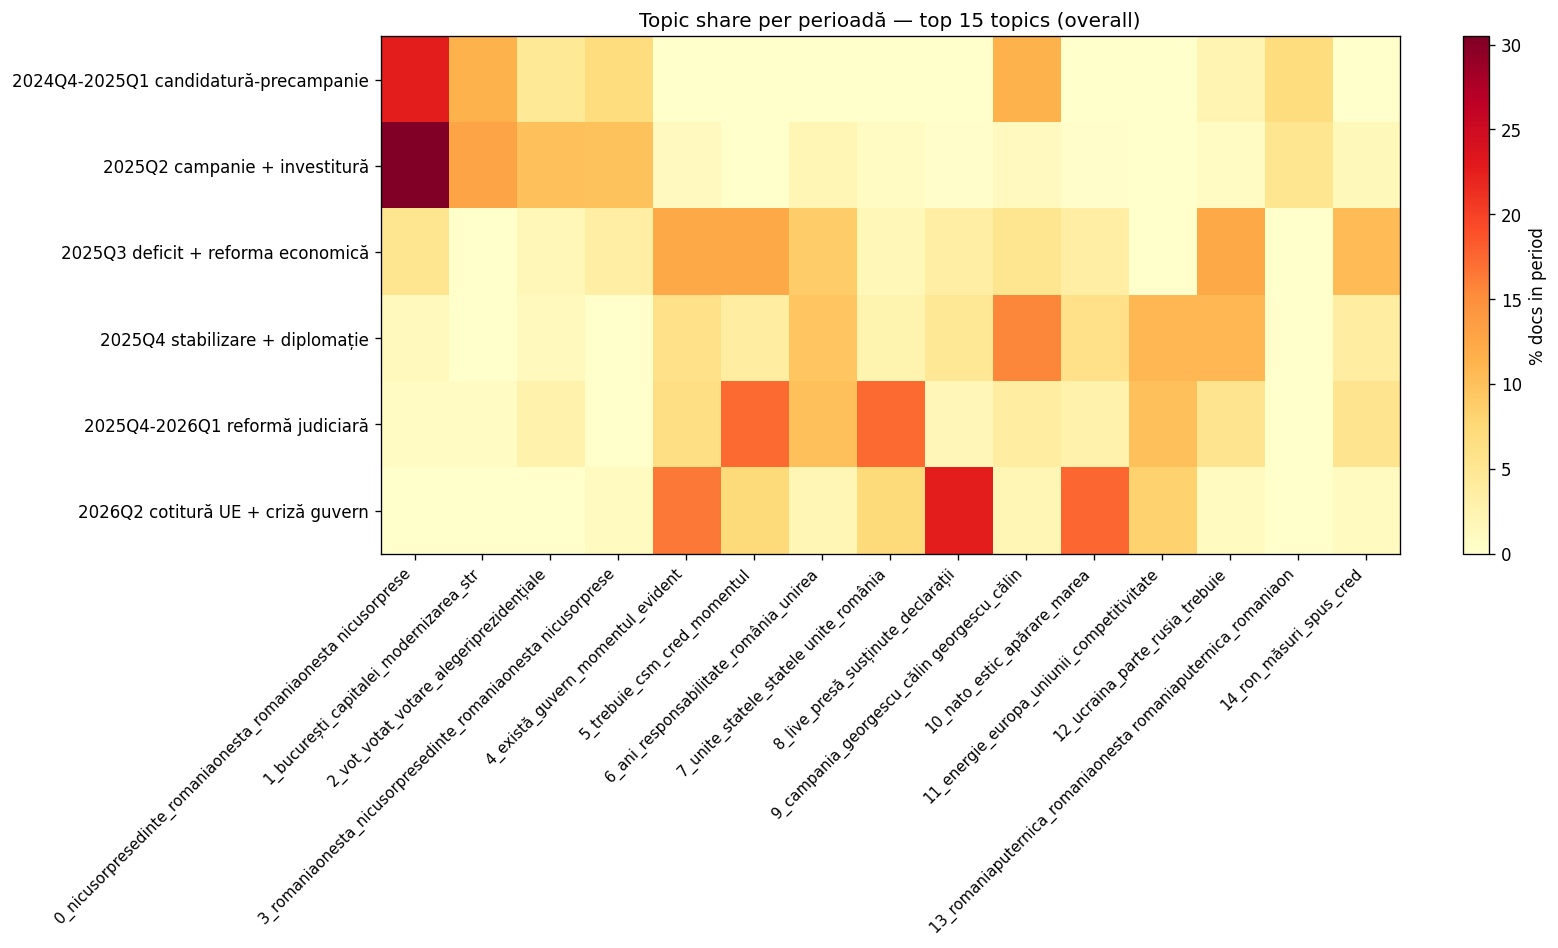

In [9]:
from IPython.display import Image
Image("results/03_bertopic_overall/topics_over_time.png")

## 7. Zip rezultate + descarcă

Rulează cell-ul ăsta, apoi `bertopic_results.zip` va apărea în panoul Files (stânga). Click-dreapta → Download.

In [10]:
!zip -r bertopic_results.zip results/03_bertopic_overall results/03_bertopic_scris results/03_bertopic_vorbit
from google.colab import files
files.download('bertopic_results.zip')

  adding: results/03_bertopic_overall/ (stored 0%)
  adding: results/03_bertopic_overall/topics.csv (deflated 82%)
  adding: results/03_bertopic_overall/topic_info.md (deflated 73%)
  adding: results/03_bertopic_overall/model/ (stored 0%)
  adding: results/03_bertopic_overall/model/topic_embeddings.safetensors (deflated 41%)
  adding: results/03_bertopic_overall/model/ctfidf_config.json (deflated 72%)
  adding: results/03_bertopic_overall/model/ctfidf.safetensors (deflated 64%)
  adding: results/03_bertopic_overall/model/config.json (deflated 44%)
  adding: results/03_bertopic_overall/model/topics.json (deflated 79%)
  adding: results/03_bertopic_overall/topics_over_time.png (deflated 14%)
  adding: results/03_bertopic_scris/ (stored 0%)
  adding: results/03_bertopic_scris/topics.csv (deflated 82%)
  adding: results/03_bertopic_scris/topic_info.md (deflated 61%)
  adding: results/03_bertopic_scris/model/ (stored 0%)
  adding: results/03_bertopic_scris/model/topic_embeddings.safetensors

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (Alternativă) Push înapoi pe GitHub direct din Colab

Necesită Personal Access Token. Skip dacă preferi download local.

In [ ]:
# Uncomment + adaugă tokenul tău
# !git config user.email "radu.stochitoiu@gmail.com"
# !git config user.name "Radu Stochitoiu"
# !git add results/03_bertopic_overall results/03_bertopic_scris results/03_bertopic_vorbit
# !git commit -m "BERTopic — rezultate pe overall/scris/vorbit (rulat în Colab T4)"
# !git push https://<USERNAME>:<TOKEN>@github.com/radusqrt/evolutie-discurs-nicusor-dan.git main